In [10]:
# data augmentation
import torchvision.transforms as transforms
import torch.utils.data as data
import torchvision.datasets as datasets
import torch
import os

BATCH_SIZE = 32
IMG_SIZE = (256, 256)
ROOT = '../data/clean/'

'''Ajout de transformations pour augmenter les données d'entraînement et améliorer la généralisation du modèle.
    Pour le test et la validation, nous appliquons uniquement les transformations de base pour garantir une évaluation cohérente.'''

transform_all = transforms.Compose([transforms.Resize(IMG_SIZE),
                                transforms.ToTensor(),
                                transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
                                ])
transform_train = transforms.Compose([transforms.Resize(IMG_SIZE),
                                transforms.RandomHorizontalFlip(),
                                transforms.RandomRotation(15),
                                transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
                                transforms.ToTensor(),
                                transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
                                ])

train_dataset = datasets.ImageFolder(root=ROOT+"train", transform=transform_train)
train_loader = data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_dataset = datasets.ImageFolder(root=ROOT+"val", transform=transform_all)
val_loader = data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
test_dataset = datasets.ImageFolder(root=ROOT+"test", transform=transform_all)
test_loader = data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Using device: {device}')


Using device: cuda


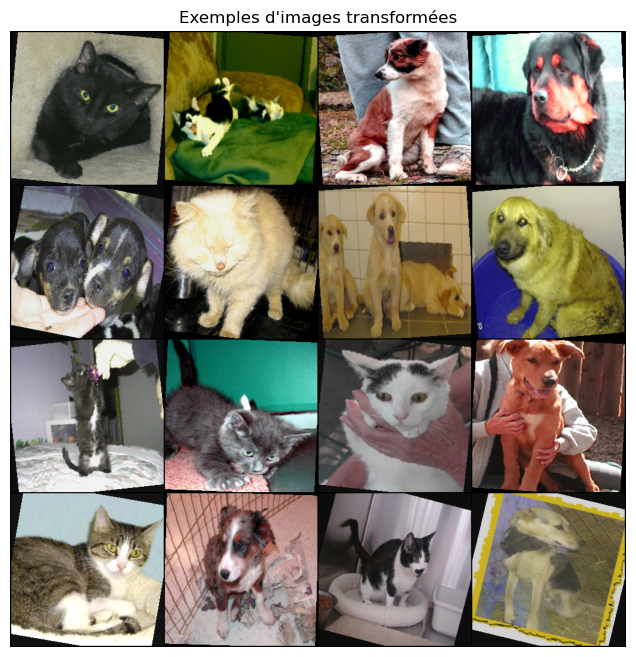

In [11]:
#visualisation des images après transformation

import matplotlib.pyplot as plt
import numpy as np
import torchvision.utils as utils

batch = next(iter(train_loader))
images, labels = batch
# Denormaliser les images pour les afficher correctement
images = images * 0.5 + 0.5  # Inverser la normalisation
grid_img = utils.make_grid(images[:16], nrow=4)  # Afficher les 16 premières images
plt.figure(figsize=(8, 8))
plt.imshow(np.transpose(grid_img.numpy(), (1, 2, 0)))
plt.title('Exemples d\'images transformées')
plt.axis('off')
plt.show()


In [12]:
import torch.nn as nn

#ajout de couches de dropout pour éviter le surapprentissage et du batch normalization pour accélérer la convergence et améliorer la performance du modèle
class OptimizedCNN(nn.Module):
    def __init__(self):
        #recuperation de la classe parente nn.Module
        super(OptimizedCNN, self).__init__()

        
        layers = []
        in_channels = 3 # 3 canaux pour les images RGB
        out_channels = 16 #je commence avec 16 filtres pour la convolutions

        for _ in range(5): #5 couches pour arrivés a une taille d'images de 8x8
            layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1))
            layers.append(nn.BatchNorm2d(out_channels)) # Batch normalization après chaque convolution
            layers.append(nn.ReLU())
            layers.append(nn.MaxPool2d(2, 2))
            in_channels = out_channels
            out_channels *= 2
        self.features= nn.Sequential(*layers)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear((out_channels//2)*8*8, 256), # 256 filtres et une taille d'image de 8x8
            nn.Dropout(0.5), # pour éviter le surapprentissage
            nn.ReLU(),
            nn.Linear(256, 2) # 2 classes (dog et cat)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [13]:
model = OptimizedCNN().to(device)
criterion = nn.CrossEntropyLoss() #fonction de perte pour les problèmes de classification multi-classes
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
epochs = 100

PATH_MODEL = '../models/'
# variable pour early stopping
best_val_loss = float('inf')
patience = 5
patience_counter = 0

#variable pour visualiation des courbes
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

In [14]:

# Boucle d'entrainement
for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    train_correct = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad() #remettre les gradients à 0

        outputs = model(images) #prediction

        loss = criterion(outputs, labels) #calcul de la perte

        loss.backward()#calcul des gradients

        optimizer.step()#mise a jour des poids

        train_loss += loss.item() #on ajoute l'erreur de ce batch à la perte totale de l'epoch
        _, predicted = torch.max(outputs.data, 1) #prediction de la classe (chat = 0, chien = 1)
        total_train += labels.size(0) #nombre total d'images traitées
        train_correct += (predicted == labels).sum().item() #nombre d'images correctement classées




    train_loss = train_loss / len(train_loader) #on divise la perte totale par le nombre de batchs pour obtenir la perte moyenne par batch
    train_accuracy = train_correct / total_train
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    # Validation
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad(): #on désactive le calcul des gradients pour la validation
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_accuracy = val_correct / val_total
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f}')

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), os.path.join(PATH_MODEL, f'optimized_model.pth')) #sauvegarde du meilleur modèle dans dossier models
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print("Early stopping")
        break

Epoch [1/100], Train Loss: 0.7709, Train Acc: 0.5960, Val Loss: 0.5717, Val Acc: 0.6865
Epoch [2/100], Train Loss: 0.5900, Train Acc: 0.6851, Val Loss: 0.4997, Val Acc: 0.7582
Epoch [3/100], Train Loss: 0.5319, Train Acc: 0.7383, Val Loss: 0.5243, Val Acc: 0.7414
Epoch [4/100], Train Loss: 0.4826, Train Acc: 0.7701, Val Loss: 0.4205, Val Acc: 0.8050
Epoch [5/100], Train Loss: 0.4407, Train Acc: 0.8027, Val Loss: 0.3561, Val Acc: 0.8371
Epoch [6/100], Train Loss: 0.4021, Train Acc: 0.8228, Val Loss: 0.4394, Val Acc: 0.8243
Epoch [7/100], Train Loss: 0.3656, Train Acc: 0.8432, Val Loss: 0.3034, Val Acc: 0.8731
Epoch [8/100], Train Loss: 0.3405, Train Acc: 0.8602, Val Loss: 0.2766, Val Acc: 0.8827
Epoch [9/100], Train Loss: 0.3120, Train Acc: 0.8712, Val Loss: 0.2408, Val Acc: 0.8887
Epoch [10/100], Train Loss: 0.2844, Train Acc: 0.8853, Val Loss: 0.2632, Val Acc: 0.8691
Epoch [11/100], Train Loss: 0.2676, Train Acc: 0.8878, Val Loss: 0.1823, Val Acc: 0.9215
Epoch [12/100], Train Loss: 0.

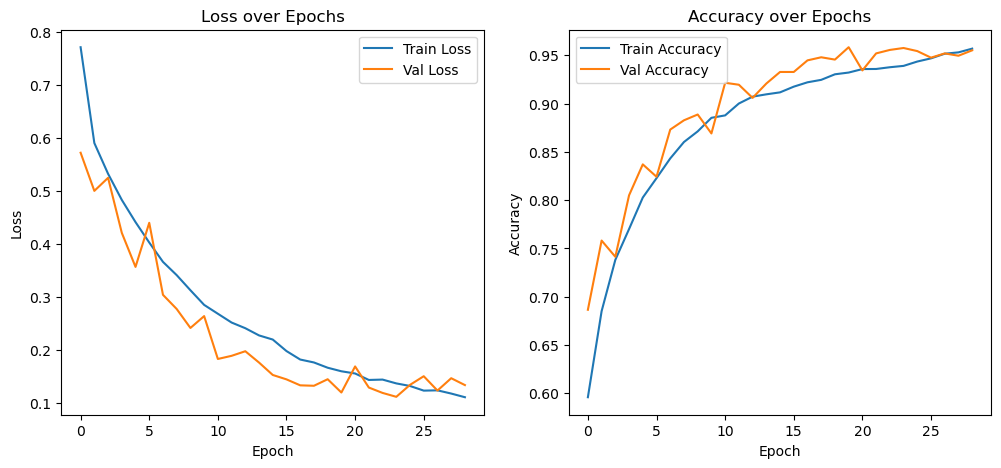

In [15]:
import matplotlib.pyplot as plt

# Tracer les courbes de perte et d'exactitude
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


# Résultat

On voit que notre modèle grâce au dropout et à la data augmentation on passe de 88.67% à 95.76% !

L'optimisation a donc eue un bonne effet, nous allons comparer nos deux modèles avec le slot de test qui n'as jamais était vue par aucun des 2 modèles.
